# Voigt Line Profiles & Order-of-Magnitude Physics Checks

A working scratch notebook of Voigt/Lorentzian line-profile code, plus a
series of independent order-of-magnitude estimates used while modelling
LSR J1835's H-alpha line and magnetosphere (broadening, inclination,
corotation/dipole geometry, Alfven radius).

Sections are independent, and can be run on their own.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import (
    G, M_sun, M_jup, R_sun, R_jup, c, k_B, m_p, h, mu0,
)
from scipy.ndimage import convolve1d
from scipy.special import voigt_profile


## 1 · Voigt line-profile convolution

Builds a normalized Voigt kernel (Gaussian x Lorentzian) on a pixel grid
and convolves a spectrum with it -- the Gaussian component captures
thermal + microturbulent broadening, the Lorentzian component captures
pressure broadening (van der Waals, Stark).

In [2]:
def voigt_kernel(sigma_pixels, gamma_pixels, kernel_width_pixels=None):
    """
    Build a normalized Voigt kernel on a pixel grid.

    Parameters
    ----------
    sigma_pixels : float
        Gaussian standard deviation in pixels.
        Relate to Gaussian FWHM via: sigma = fwhm_gauss / (2 * sqrt(2 * ln2))
        This captures thermal + turbulent broadening.
    gamma_pixels : float
        Lorentzian HWHM in pixels.
        This captures pressure (van der Waals, Stark) broadening.
    kernel_width_pixels : int, optional
        Total kernel size (forced odd). Defaults to a width that covers the
        broader of the two components generously.

    Returns
    -------
    kernel : ndarray
        Normalized Voigt kernel.
    """
    if kernel_width_pixels is None:
        # Lorentzian wings dominate extent; use the larger of the two widths
        # with a generous multiplier to capture broad pressure wings
        half_extent = max(10 * gamma_pixels, 5 * sigma_pixels)
        kernel_width_pixels = int(np.round(2 * half_extent)) + 1
        if kernel_width_pixels % 2 == 0:
            kernel_width_pixels += 1
        kernel_width_pixels = max(kernel_width_pixels, 3)

    center = kernel_width_pixels // 2
    x = np.arange(kernel_width_pixels) - center
    kernel = voigt_profile(x, sigma_pixels, gamma_pixels)
    return kernel / kernel.sum()


def convolve_voigt(flux, d_lambda,
                   fwhm_gaussian_aa, hwhm_lorentzian_aa,
                   kernel_width_pixels=None):
    """
    Convolve a spectrum with a Voigt profile using scipy.ndimage.convolve1d.

    Parameters
    ----------
    flux : array_like
        1D flux array on a uniform wavelength grid.
    d_lambda : float
        Wavelength spacing in Angstroms per pixel.
    fwhm_gaussian_aa : float
        FWHM of the Gaussian component in Angstroms.
        Thermal FWHM: fwhm_thermal = (lambda/c) * sqrt(8*ln2 * k*T / m_H)
    hwhm_lorentzian_aa : float
        HWHM of the Lorentzian component in Angstroms (gamma).
        From van der Waals or Stark broadening estimates.
    kernel_width_pixels : int, optional
        Override the default kernel width.

    Returns
    -------
    flux_conv : ndarray
        Convolved spectrum, same shape as input.
    """
    flux = np.asarray(flux, dtype=float)

    # Convert physical widths (Angstroms) to pixels
    sigma_pixels = (fwhm_gaussian_aa / (2 * np.sqrt(2 * np.log(2)))) / d_lambda
    gamma_pixels = hwhm_lorentzian_aa / d_lambda

    kernel = voigt_kernel(sigma_pixels, gamma_pixels, kernel_width_pixels)
    return convolve1d(flux, kernel, mode='reflect')


### 1a · Demo: convolving a top-hat absorption feature

Compares the Voigt-convolved profile against a pure-Gaussian convolution
of the same nominal width, so the Lorentzian wings are visible in the
difference.

Peak convolved flux: 0.3526  (input top-hat height 0.5)
Convolved FWHM (approx): 2.405 Angstrom


<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_121210/605844327.py:23: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Wavelength ($\AA$)')


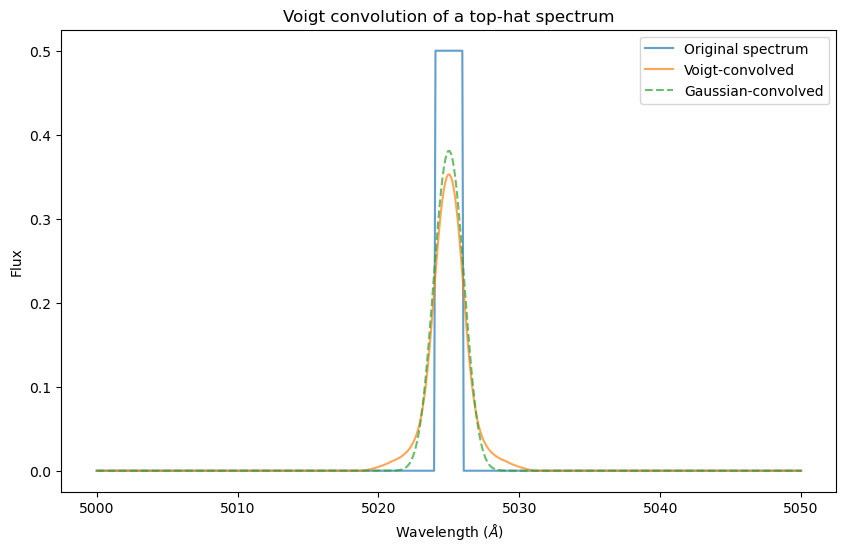

In [3]:
wavelength = np.linspace(5000, 5050, 500)  # Angstroms
flux = np.zeros_like(wavelength)
flux[(wavelength > 5024) & (wavelength < 5026)] = 0.5  # Absorption feature

d_lambda = wavelength[1] - wavelength[0]
fwhm_gaussian_aa = 1.0   # Thermal + microturbulence
hwhm_lorentzian_aa = 0.5  # Pressure broadening

convolved_flux = convolve_voigt(flux, d_lambda, fwhm_gaussian_aa, hwhm_lorentzian_aa)

# compare with a pure Gaussian convolution for reference
from scipy.ndimage import gaussian_filter1d
sigma_pixels = (fwhm_gaussian_aa / (2 * np.sqrt(2 * np.log(2)))) / d_lambda
gaussian_convolved_flux = gaussian_filter1d(flux, sigma_pixels * 2, mode='reflect')

print(f"Peak convolved flux: {convolved_flux.max():.4f}  (input top-hat height 0.5)")
print(f"Convolved FWHM (approx): {d_lambda * np.sum(convolved_flux > convolved_flux.max()/2):.3f} Angstrom")

plt.figure(figsize=(10, 6))
plt.plot(wavelength, flux, label='Original spectrum', alpha=0.7)
plt.plot(wavelength, convolved_flux, label='Voigt-convolved', alpha=0.7)
plt.plot(wavelength, gaussian_convolved_flux, label='Gaussian-convolved', alpha=0.7, linestyle='--')
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('Flux')
plt.title('Voigt convolution of a top-hat spectrum')
plt.legend()
plt.show()


## 2 · Lorentzian profile and width conversions

A standalone Lorentzian profile, plus conversions between its HWHM in
wavelength and velocity units (both directions), useful for comparing a
pressure-broadening estimate against a rotational-broadening velocity.

Lorentzian peak: 0.999 at lambda=6562.79 Angstrom


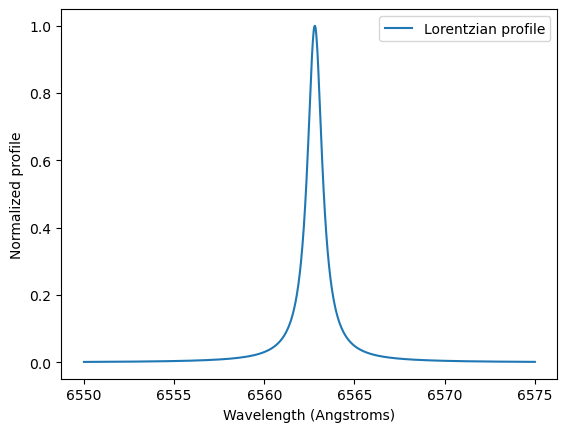

HWHM gamma=0.5 Angstrom -> full width (2*gamma)=1.00 Angstrom = 45.68 km/s
Reverse check: gamma_v=10.5 km / s -> full width in wavelength = 0.46 Angstrom


In [4]:
def lorentzian(x, x0, a, gam):
    return a * gam**2 / (gam**2 + (x - x0)**2)


x0 = 6562.8
x = np.linspace(6550, 6575, 1000)
gam = 0.5
lorentz_profile = lorentzian(x, x0, 1.0, gam)
print(f"Lorentzian peak: {lorentz_profile.max():.3f} at lambda={x[np.argmax(lorentz_profile)]:.2f} Angstrom")

plt.figure()
plt.plot(x, lorentz_profile, label='Lorentzian profile')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized profile')
plt.legend()
plt.show()

# HWHM (gamma) in wavelength -> full width in velocity
delta_lambda = 2 * gam  # Angstroms
c_kms = c.to("km/s").value
delta_v_kms = (delta_lambda / x0) * c_kms
print(f"HWHM gamma={gam} Angstrom -> full width (2*gamma)={delta_lambda:.2f} Angstrom = {delta_v_kms:.2f} km/s")

# the reverse direction: a velocity HWHM back to wavelength
gam_v = 10.5 * u.km / u.s
lam0 = 6562.8 * u.AA
delta_lambda_from_v = (2 * gam_v * lam0 / c).to(u.AA)
print(f"Reverse check: gamma_v={gam_v} -> full width in wavelength = {delta_lambda_from_v:.2f}")


## 3 · H-alpha broadening estimates (LSR J1835)

Thermal and Zeeman broadening of H-alpha, computed directly from astropy
constants and cross-checked against this project's
`funcs.broadening.thermal_broadening_sigma` helper.

In [5]:
lambda_ = 6562.8 * u.AA
T = 8000 * u.K
fwhm_thermal = (lambda_ / c) * np.sqrt(8 * np.log(2) * k_B * T / m_p)
print(f"Thermal FWHM at T={T}: {fwhm_thermal.to(u.AA):.4f}")

from funcs.broadening import thermal_broadening_sigma
val_10000 = thermal_broadening_sigma(10000)
val_8000 = thermal_broadening_sigma(8000)
print(f"funcs.broadening.thermal_broadening_sigma(10000 K) = {val_10000:.3f} km/s")
print(f"funcs.broadening.thermal_broadening_sigma(8000 K)  = {val_8000:.3f} km/s")


print()
B = 3 * u.kG
mu_B = 9.274009994e-24 * u.J / u.T
g_eff = 1.0  # Effective Lande g-factor for H-alpha
lam0 = 6562.8 * u.AA
delta_E = mu_B * g_eff * B
delta_lambda_zeeman = (delta_E / (h * c / lam0**2)).to(u.AA)
print(f"Zeeman splitting at B={B}, g_eff={g_eff}: delta_lambda = {delta_lambda_zeeman:.3f}")
delta_v_zeeman = (delta_lambda_zeeman / lam0) * c.to(u.km / u.s)
print(f"Zeeman splitting in velocity: delta_v = {delta_v_zeeman:.2f}")


Thermal FWHM at T=8000.0 K: 0.4189 Angstrom
funcs.broadening.thermal_broadening_sigma(10000 K) = 9.085 km/s
funcs.broadening.thermal_broadening_sigma(8000 K)  = 8.126 km/s

Zeeman splitting at B=3.0 kG, g_eff=1.0: delta_lambda = 0.060 Angstrom
Zeeman splitting in velocity: delta_v = 2.76 km / s


## 4 · Stellar rotation & inclination from v sin(i*)

Equatorial velocity from radius and rotation period, inclination implied
by a single v sin(i*) measurement, and the (unweighted) average of the
literature v sin(i*) values used in the posterior below.

In [6]:
vsini = 48 * u.km / u.s
R = 1.12 * u.R_jup
P_rot = 2.845 * u.h
veq = (2 * np.pi * R / P_rot).to(u.km / u.s)
print(f"Equatorial velocity: {veq:.2f}")
sini = (vsini / veq).decompose().value
i = np.arcsin(sini) * 180 / np.pi
print(f"sin(i) = {sini:.4f}  ->  inclination i = {i:.2f} deg")

print()
vsini1, vsinierr1 = 50, 5        # Berger+2008
vsini2, vsinierr2 = 49.2, 4.9    # Reiners+2018
vsini3, vsinierr3 = 43.9, 2.2    # Crossfield+2014
vsini4, vsinierr4 = 43.7, 3.5    # Varas+2026
combined_vsini = (vsini1 + vsini2 + vsini3 + vsini4) / 4
combined_sigma = np.sqrt(vsinierr1**2 + vsinierr2**2 + vsinierr3**2 + vsinierr4**2) / 4
print(f"Combined v sin(i*): {combined_vsini:.2f} +/- {combined_sigma:.2f} km/s")

print()
R_star = 1.07 * u.R_jup
P_rot_adopted = 2.845 * u.h
v_eq = (2 * np.pi * R_star / P_rot_adopted).to(u.km / u.s)
print(f"v_eq(R={R_star}, P_rot={P_rot_adopted}) = {v_eq:.2f}")


Equatorial velocity: 49.12 km / s
sin(i) = 0.9772  ->  inclination i = 77.73 deg

Combined v sin(i*): 46.70 +/- 2.03 km/s

v_eq(R=1.07 jupiterRad, P_rot=2.845 h) = 46.93 km / s


## 5 · Posterior on stellar inclination

Combines each literature v sin(i*) measurement with the equatorial
velocity (from radius + rotation period, each with its own uncertainty)
into a posterior on inclination i*, following
P(i*|d) ~ sin(i*) * exp(-(v sin i* - v_eq sin i*)^2 / (2*var)) / sqrt(var).
Plots one curve per source plus the combined estimate, and prints the
peak-posterior inclination for each.

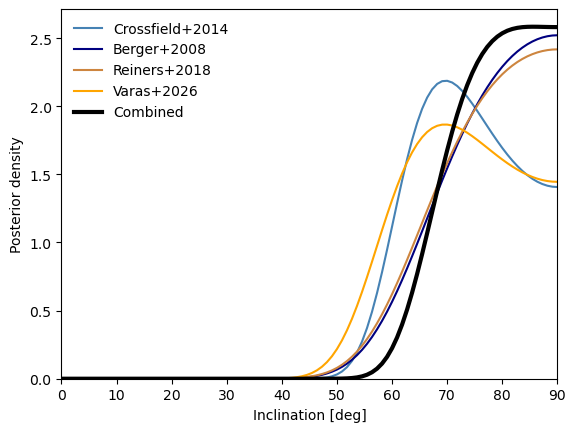

Peak-posterior inclination per v*sin(i*) source:
  Crossfield+2014  i_peak =  70.0 deg
  Berger+2008      i_peak =  90.0 deg
  Reiners+2018     i_peak =  90.0 deg
  Varas+2026       i_peak =  70.0 deg
  Combined         i_peak =  85.5 deg


In [7]:
def posterior_inclination(i_star, v_sin_i, R_star, P_rot, sigma_v_sin_i, sigma_v_eq):
    """
    Computes the unnormalized posterior probability of stellar inclination i*.

    P(i* | d) ~ sin(i*) * exp(-(...**2) / (2*(sig2_v_sin_i + sig2_v_eq*sin^2(i*))))
                          / sqrt(sig2_v_sin_i + sig2_v_eq*sin^2(i*))

    Parameters
    ----------
    i_star        : float or array  Inclination angle [radians]
    v_sin_i       : float           Observed projected velocity v*sin(i*) [km/s]
    R_star        : float           Stellar radius [km or consistent units]
    P_rot         : float           Rotation period [s or consistent units]
    sigma_v_sin_i : float           Uncertainty on v*sin(i*) [km/s]
    sigma_v_eq    : float           Uncertainty on equatorial velocity v_eq [km/s]

    Returns
    -------
    float or array : Unnormalized posterior probability
    """
    sin_i = np.sin(i_star)
    v_eq = (2 * np.pi * R_star) / P_rot
    variance = sigma_v_sin_i**2 + sigma_v_eq**2 * sin_i**2
    delta = v_sin_i - v_eq * sin_i
    exponent = -delta**2 / (2 * variance)
    return sin_i * np.exp(exponent) / np.sqrt(variance)


i_star = np.linspace(0, np.pi / 2, 100)
R_star = 1.07 * u.R_jup
P_rot = 2.845 * u.h
sigma_R_star = 0.05 * u.R_jup
sigma_veq = (2 * np.pi * sigma_R_star / P_rot).to(u.km / u.s)

literature = [
    (43.9, 2.2, "Crossfield+2014", "steelblue"),
    (50.0, 5.0, "Berger+2008", "navy"),
    (49.2, 4.9, "Reiners+2018", "peru"),
    (43.7, 3.5, "Varas+2026", "orange"),
    (46.7, 2.03, "Combined", "k"),
]

plt.figure()
peak_i = {}
for v_sin_i, sigma_v_sin_i, label, color in literature:
    posterior = posterior_inclination(
        i_star, v_sin_i, R_star.to(u.km).value, P_rot.to(u.s).value,
        sigma_v_sin_i, sigma_veq.value,
    )
    posterior /= np.trapezoid(posterior, i_star)
    peak_i[label] = np.degrees(i_star[np.argmax(posterior)])
    lw = 3 if label == "Combined" else 1.5
    plt.plot(np.degrees(i_star), posterior, label=label, color=color, lw=lw)

plt.xlabel('Inclination [deg]')
plt.xlim(0, 90)
plt.ylim(0, None)
plt.ylabel('Posterior density')
plt.legend(frameon=False)
plt.savefig("inclination_posterior.png", dpi=300, bbox_inches="tight")
plt.show()

print("Peak-posterior inclination per v*sin(i*) source:")
for label, i_peak in peak_i.items():
    print(f"  {label:16} i_peak = {i_peak:5.1f} deg")


## 6 · Corotation radius & dipole field-line geometry (LSR J1835)

Corotation radius at the measured rotation period (and a slower
hypothetical one for comparison), where a dipole field line anchored at a
given corotation radius crosses the stellar surface, and a trace of that
field line.

P_rot=2.845 h: r_corotation = 4.14 jupiterRad
P_rot=180.0 h (hypothetical, for comparison): r_corotation = 65.73 jupiterRad

For r_companion = 23.0 jupiterRad: footprint latitude = 77.54 deg

field line spans x in [0.00 jupiterRad, 22.99 jupiterRad], z in [-8.85 jupiterRad, 8.85 jupiterRad]


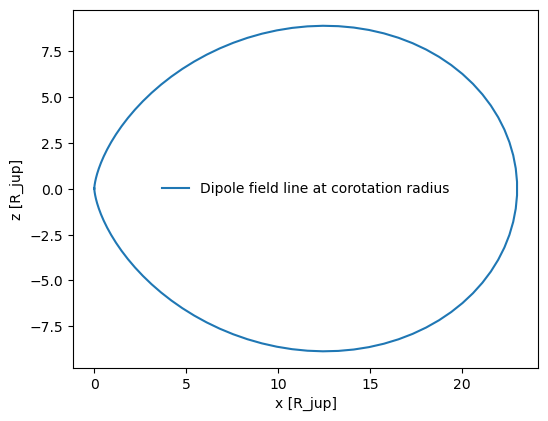

In [8]:
m_lsr = 77 * M_jup
r_lsr = 1.07 * R_jup

Prot = 2.845 * u.h
r_corotation = (G * m_lsr * Prot**2 / (4 * np.pi**2)) ** (1 / 3)
print(f"P_rot={Prot}: r_corotation = {r_corotation.to(u.R_jup):.2f}")

T_slow = 180 * u.h
r_corotation_slow = (np.power(T_slow**2 * G * m_lsr / (4 * np.pi**2), 1 / 3)).to(u.R_jup)
print(f"P_rot={T_slow} (hypothetical, for comparison): r_corotation = {r_corotation_slow:.2f}")

print()
r_companion = 23 * R_jup
lat_footprint = 90 * u.deg - (np.arcsin(np.sqrt(r_lsr / r_companion))).to(u.deg)
print(f"For r_companion = {r_companion.to(u.R_jup):.1f}: footprint latitude = {lat_footprint:.2f}")

print()
theta = np.linspace(0, np.pi, 100)  # colatitude along the field line
r_line = r_companion * np.sin(theta) ** 2  # dipole field line: r = L*cos^2(magnetic latitude)
z = (r_line * np.sin(np.pi / 2 - theta)).to(u.R_jup)
x = (r_line * np.cos(np.pi / 2 - theta)).to(u.R_jup)
print(f"field line spans x in [{x.min():.2f}, {x.max():.2f}], z in [{z.min():.2f}, {z.max():.2f}]")

plt.figure(figsize=(6, 6))
plt.plot(x, z, label="Dipole field line at corotation radius")
plt.xlabel("x [R_jup]")
plt.ylabel("z [R_jup]")
plt.gca().set_aspect("equal")
plt.legend(frameon=False)
plt.show()


## 7 · Orbital-phase window consistency checks

How much orbital phase a 9h observing window covers at an assumed orbital
distance, and the reverse: what orbital distance is implied by assuming a
given number of orbits fit into that window.

In [9]:
m_lsr = 77 * M_jup
d = 23 * u.R_jup
T_orb = 2 * np.pi * np.sqrt(d**3 / (G * m_lsr))
phase_deg = ((9 * u.h) / T_orb).decompose() * 360
print(f"Orbital period at d={d}: {T_orb.to(u.h):.2f}")
print(f"Phase covered by a 9h window: {phase_deg:.2f} deg")

# Compared against the longitude difference between the 173 deg spot 5 
# and the 86 deg spot 1
remainder_deg = 173 - 86
print(f"Remainder against a 173 deg feature separation (using the ~86 deg "
      f"estimate above): {remainder_deg} deg")

print()
n_orbits = 9 / 2.845 + 0.25
orb_per = 9 / n_orbits * u.h
d_fit = ((orb_per / (2 * np.pi)) ** 2 * (G * m_lsr)) ** (1 / 3)
print(f"Assuming {n_orbits:.3f} orbits fit in 9h (period {orb_per:.3f}): "
      f"implied orbital distance = {d_fit.to(u.R_jup):.2f}")


Orbital period at d=23.0 jupiterRad: 37.26 h
Phase covered by a 9h window: 86.96 deg
Remainder against a 173 deg feature separation (using the ~86 deg estimate above): 87 deg

Assuming 3.413 orbits fit in 9h (period 2.637 h): implied orbital distance = 3.93 jupiterRad


## 8 · Magnetospheric density profile & Alfven radius (LSR J1835)

A corotating vs. non-corotating density profile out to 150 R_jup, then the
Alfven radius across a grid of surface field strengths and plasma
densities.

density at R=10 R_jup: with corotation = 1.19e+05 1 / cm3, without = 1.19e+05 1 / cm3


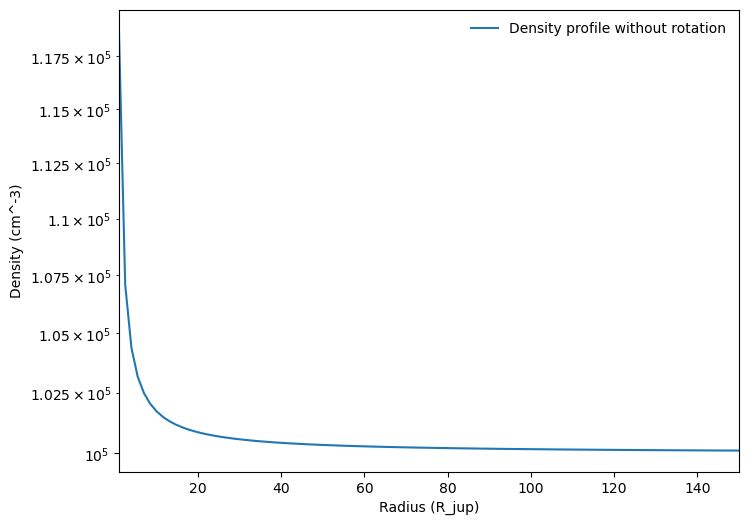


Alfven radius grid shape: (100, 50), range [2.89, 29.71] R_jup
e.g. at n=1.2e+05 1 / cm3, B0=10 G:  R_A = 2.89 R_jup
e.g. at n=1.2e+05 1 / cm3, B0=1e4 G: R_A = 28.88 R_jup


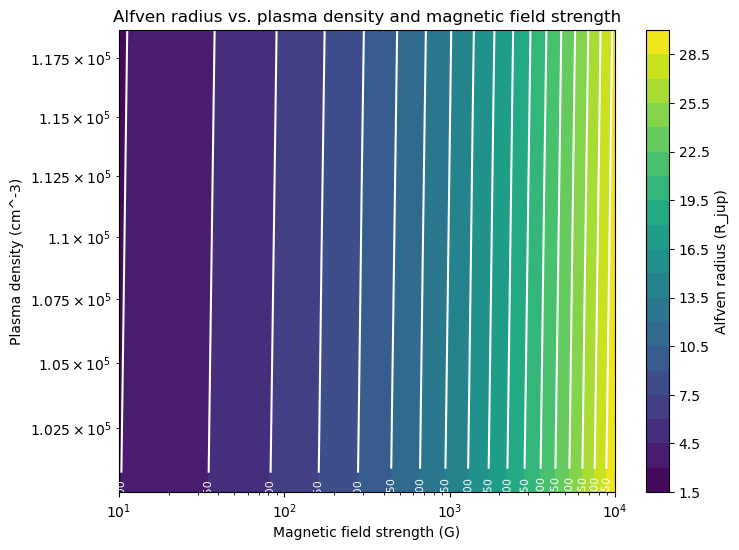

In [10]:
n0 = 1e5 * u.cm ** (-3)
Tc = 5e7 * u.K
m_lsr_alfven = 80 * M_jup
Prot_alfven = 2.845 * u.h
A = (G * m_lsr_alfven * m_p) / (2 * k_B * Tc)
omega = 2 * np.pi / Prot_alfven
Bcoef = (omega**2 * m_p / (2 * k_B * Tc))
R = np.linspace(1, 150, 100) * R_jup
n_with_rotation = (n0 * np.exp(A / R + Bcoef / 2 * R**2)).to(u.cm ** (-3))
n_no_rotation = (n0 * np.exp(A / R)).to(u.cm ** (-3))
i10 = np.argmin(np.abs(R.value - 10))
print(f"density at R=10 R_jup: with corotation = {n_with_rotation[i10]:.2e}, "
      f"without = {n_no_rotation[i10]:.2e}")

plt.figure(figsize=(8, 6))
plt.plot(R / R_jup, n_no_rotation, label="Density profile without rotation")
plt.xlabel("Radius (R_jup)")
plt.ylabel("Density (cm^-3)")
plt.xlim(1, 150)
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

print()
Rx = 1.07 * R_jup
def alfven_radius_rjup(n, Tc, B0):
    return (((8 * np.pi * k_B * Tc * n) / (B0**2 * Rx**6 / mu0)) ** (-1 / 6) / R_jup).decompose().value

B0 = np.logspace(1, 4) * u.G
n_grid, B0_grid = np.meshgrid(n_no_rotation, B0, indexing="ij")
ra_grid = alfven_radius_rjup(n_grid, Tc, B0_grid)
print(f"Alfven radius grid shape: {ra_grid.shape}, range [{ra_grid.min():.2f}, {ra_grid.max():.2f}] R_jup")
print(f"e.g. at n={n_no_rotation[0]:.1e}, B0=10 G:  R_A = {ra_grid[0, 0]:.2f} R_jup")
print(f"e.g. at n={n_no_rotation[0]:.1e}, B0=1e4 G: R_A = {ra_grid[0, -1]:.2f} R_jup")

plt.figure(figsize=(8, 6))
cf = plt.contourf(B0_grid.to(u.G), n_grid.to(u.cm ** (-3)), ra_grid, levels=20, cmap="viridis")
plt.colorbar(cf, label="Alfven radius (R_jup)")
contours = plt.contour(B0_grid.to(u.G), n_grid.to(u.cm ** (-3)), ra_grid, levels=20, colors="white")
plt.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
plt.xlabel("Magnetic field strength (G)")
plt.ylabel("Plasma density (cm^-3)")
plt.xscale("log")
plt.yscale("log")
plt.title("Alfven radius vs. plasma density and magnetic field strength")
plt.show()


## 9 · Toy hot-Jupiter phase-curve amplitudes (generic reference)

Order-of-magnitude phase-curve amplitudes -- Doppler boosting, ellipsoidal
variation, transit depth, reflected/intercepted luminosity -- for a
generic hot-Jupiter system. Not LSR J1835; these are reference scales from
an unrelated back-of-envelope check.

In [11]:
T = 2 * u.day
theta = 60 / 180 * np.pi   # orbital inclination relative to face-on
r = (G * M_sun * T**2 / (4 * np.pi**2)) ** (1 / 3)
v_pl = (np.sqrt(G * M_sun / r)).decompose()
beta = M_jup / M_sun * v_pl * np.sin(theta) / c
doppler_boost = ((1 + beta) / (1 - beta)) ** 4 - 1
print(f"Orbital distance for P={T}: {r.to(u.au):.4f}")
print(f"Doppler boosting amplitude (alpha=4): {doppler_boost:.3e}")

alph_ellipsoidal = 2.0
R_star = 1 * u.R_sun
M_planet = M_jup
M_star = M_sun
ampl_ellipsoidal = (13 * alph_ellipsoidal * np.sin(theta) * (R_star / R_sun) ** 3
                     * (M_star / M_sun) ** (-2) * (T / u.day) ** (-2)
                     * (M_planet * np.sin(theta) / M_jup)).decompose()
print(f"Ellipsoidal variation amplitude: {ampl_ellipsoidal:.2f} ppm")

R_planet = 1 * u.R_jup
transit_depth_ppm = ((R_planet / R_star) ** 2).decompose() * 1e6 * 0.5 * 0.5
print(f"Transit depth (x0.25 geometric factor): {transit_depth_ppm:.1f} ppm")

L_star = 1 * u.L_sun
L_at_planet = L_star / (4 * np.pi * r**2) * np.pi * R_planet**2
frac_intercepted = (L_at_planet / L_star).decompose()
print(f"Fraction of stellar luminosity intercepted by the planet: {frac_intercepted:.3e}")

print()
h0 = M_planet / M_star * R_star**4 / r**3
r0 = R_sun
a = R_sun + h0
b = np.sqrt(r0**3 / (r0 + h0))
A_big = np.pi * a * b
A_small = np.pi * (r0 - h0) ** 2
area_frac = ((A_big - A_small) / A_small).decompose()
print(f"Grazing-geometry fractional area difference: {area_frac:.3e}")


Orbital distance for P=2.0 d: 0.0311 AU
Doppler boosting amplitude (alpha=4): 3.728e-06
Ellipsoidal variation amplitude: 4.87 ppm
Transit depth (x0.25 geometric factor): 2640.0 ppm
Fraction of stellar luminosity intercepted by the planet: 5.916e-05

Grazing-geometry fractional area difference: 8.005e-06


## 10 · Atmosphere, photon-flux, and unit-conversion references

Ideal-gas number density from pressure, photon-energy/flux conversions, a
few solid-angle sanity checks, R_jup unit conversions, and
magnitude-difference-to-flux-ratio -- generic reference calculations.

In [ ]:
def number_density(p, T):
    """Ideal-gas number density from pressure and temperature."""
    return (p / (k_B * T)).to(u.cm ** (-3))

p = 1e-3 * u.bar
T = 2400 * u.K
density = number_density(p, T)
print(f"n(p={p}, T={T}) = {density:.2e}")

print()
h_planck = 6.62607015e-34 * u.J * u.s
c_light = 299792458 * u.m / u.s
lam = 195 * u.AA
E = (h_planck * c_light / lam).to(u.J)
print(f"Energy of 1e10 photons at {lam}: {(E * 1e10):.2e}")
power = (E * 1e10) / u.cm ** 2 / u.s / u.AA
flux = (power * 4 * u.AA).to(u.W / u.m ** 2)
print(f"Corresponding flux (over a 4 AA bandpass): {flux:.4f}")

flux_1au = (1e17 * u.W / (np.pi * 1 * u.AU ** 2)).to(u.W / u.m ** 2)
print(f"Flux at 1 AU from a 1e17 W source: {flux_1au:.3e}")

print()
print(f"0.5*(1-cos(45 deg)) = {0.5 * (1 - np.cos(np.radians(45))):.4f}")
print(f"arcsin(sqrt(4*pi/1500)) = {np.degrees(np.arcsin(np.sqrt(4 * np.pi / 1500))):.2f} deg")
area_1deg_cap = 2 * np.pi * R_sun ** 2 * (1 - np.cos(np.radians(1)))
print(f"Spherical-cap area for a 1 deg half-angle on the Sun: {area_1deg_cap:.3e}")

print()
print(f"1882700 km = {(1882700 * u.km / u.R_jup).decompose():.3f} R_jup")
print(f"0.1 R_jup = {(0.1 * u.R_jup).to(u.km):.1f}")

print()
def mag_to_flux(mag_diff):
    """Convert a magnitude difference to a flux ratio."""
    return 10 ** (-0.4 * mag_diff)

mag_diff = 0.013
print(f"mag_diff={mag_diff} -> flux ratio = {mag_to_flux(mag_diff):.4f}")


n(p=0.001 bar, T=2400.0 K) = 3.02e+15 1 / cm3

Energy of 1e10 photons at 195.0 Angstrom: 1.02e-07 J
Corresponding flux (over a 4 AA bandpass): 0.0041 W / m2
Flux at 1 AU from a 1e17 W source: 1.422e-06 W / m2

0.5*(1-cos(45 deg)) = 0.1464
arcsin(0.5) = 30.0 deg  (sanity check)
arcsin(sqrt(4*pi/1500)) = 5.25 deg
Spherical-cap area for a 1 deg half-angle on the Sun: 4.632e+14 m2

1882700 km = 26.334 R_jup
0.1 R_jup = 7149.2 km

mag_diff=0.013 -> flux ratio = 0.9881
